# Notebook Objectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
from pyscripts.heavy_atom_rmsd import *
#from _02_write_viollin_data import HeavyAtom_Analyzer
def save_dcd(fname, traj_xyz):
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)    

In [2]:
base_dict = {"VAE_RMSD": None,
             "VAE_LOSS_RMSD": None,
             "PCA_RMSD": None,
             "PCA_LOSS_RMSD": None}

def load_files(numpy_files, verbose=True):
    fns = sorted(numpy_files)
    attrs = [fn.split('/')[1:] if fn.split('/')[0] == 'numpy_backups' else fn.split('/') for fn in fns]
    model_name = attrs[0][0]
    assert False not in [elem[0] == model_name for elem in attrs]
    
    model_data = {}
    for attr_set in attrs:
        n_latents = int(attr_set[1].split('_')[0])
        if n_latents not in model_data.keys():
            model_data[n_latents] = {}
        rpt = attr_set[2]
        if rpt not in model_data[n_latents].keys():
            model_data[n_latents][rpt] = deepcopy(base_dict)

        try:
            if attr_set[-1].split('.')[0] in [key for key in base_dict.keys()]:
                model_data[n_latents][rpt][attr_set[-1].split('.')[0]] = np.load(os.path.join(*attr_set))
            else:
                if verbose:
                    print(f"Excluding ", os.path.join(*attr_set))
        except:
            if verbose:
                    print(f"Failure on", os.path.join(*attr_set))
            
    return model_data

def lowest_rpts(chart_data):
    means = {}

    for key, val in chart_data.items():
        if key not in means.keys():
            means[key] = {}
        for key2, val2 in chart_data[key].items():
            if key2 not in means[key].keys():
                means[key][key2] = {}
            for key3, val3 in chart_data[key][key2].items():
                means[key][key2][key3] = np.mean(chart_data[key][key2][key3])
    
    best_rpts_RMSD = {key: None for key in means.keys()}
    best_rpts_LOSS = {key: None for key in means.keys()}
    
    for key, val in means.items():
        #discover the lowest mean rpt
        best_rpts_RMSD[key] = min(val.items(), key=lambda x: x[-1]['VAE_RMSD'])[0]
        best_rpts_LOSS[key] = min(val.items(), key=lambda x: x[-1]['VAE_LOSS_RMSD'])[0]
    
    return means, best_rpts_RMSD, best_rpts_LOSS

#### Clustering Accuracy

Assign "True" labels by clustering the test set data in the atomistic space\
Then assign predicted labels for each of PCA and Encoding for each of Latents

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datetime import datetime

from _02_write_viollin_data import HeavyAtom_Analyzer

decode_pca = lambda data, pca: pca.inverse_transform(pca.transform(heavy_atom_analyzer.data))

In [2]:
#Obtain the test set date from the VAE Model
HA = HeavyAtom_Analyzer(json_fn='json_inputs/X013-2/CR_X013-2/CR_X013-2_0002_01.json')

XlaRuntimeError: FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version

In [ ]:
### CHANGE ME IF NECESSARY !!!!
traj = md.load('Simulation/ala_deca_peptide.pdb')
#traj = md.load('Simulation/1crn_split2.dcd', top='Simulation/1crn_H.prmtop')
#traj = md.load('Simulation/3mxf_protein_ligand.pdb')

In [ ]:
heavy_atom_indices = traj.top.select('not element H')
frames2heavy = lambda frames: frames.reshape(frames.shape[0], -1, 3)[:, heavy_atom_indices, :].reshape(frames.shape[0], -1)
test_frames = frames2heavy(self.experiments['2 Latents'].test_data)
del traj

In [ ]:
one_off_rmsd = lambda a, b: jnp.sqrt(jnp.mean(jnp.sum((b.reshape(-1, 3) - a.reshape(-1, 3))**2, axis=1)))
assert False not in [jnp.all(self.experiments['2 Latents'].test_data == self.experiments[key].test_data) for key in self.experiments.keys()]

#Get distance matrix of the test frames
def dist_matrix_row(a, bs):
    return jax.vmap(one_off_rmsd, in_axes=(None, 0))(a, bs)

def rmsd_distance_matrix(frames):
    dist_mat = jnp.empty((frames.shape[0], frames.shape[0]))
    for i in range(frames.shape[0]):
        dist_mat = dist_mat.at[i].set(dist_matrix_row(frames[i], frames))
    return dist_mat

test_distance_matrix = rmsd_distance_matrix(test_frames)

In [ ]:
start = datetime.now()
labels_Kmeans = KMeans(n_clusters=6).fit_predict(test_frames)
check1 = datetime.now()
print(f"Time for Kmeans was {check1 - start}")
labels_Agg = AgglomerativeClustering(n_clusters=6, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
check2 = datetime.now()
print(f"Time for Agglomerative was {check2 - check1}")
labels_HDB = HDBSCAN(metric='precomputed').fit_predict(test_distance_matrix)
check3 = datetime.now()
print(f"Time for HDBScan was {check3 - check2}")

In [ ]:
hdbscan_epsilons = np.linspace(0, test_distance_matrix.max())

In [ ]:
plt.matshow(test_distance_matrix)
plt.colorbar()

In [ ]:
#Entries {key=name, value=clustering_method}
clustering_methods = {'KMeans': KMeans,
                      'Agglomerative': AgglomerativeClustering,
                      'HDBScan': HDBSCAN}
methods_without_nums_clusters = ['HDBScan']

#Entries {key=name, value=[function, is_supervised]}
metric_functions = {"Rand Score":[rand_score, True],
                    "normalized MI Score":[normalized_mutual_info_score, True],
                    "Fowlkes-Mallows Score":[fowlkes_mallows_score, True],
                    "Silhouette Score":[silhouette_score, False],
                    "Davies-Bouldin Score":[davies_bouldin_score, False],
                    "Calinksi-Harabasz Score":[calinski_harabasz_score, False]}


def num_clusters_by_method(method_name, min_clusters=2, max_clusters=40, num_repetitions=5, plot=False):
    assert method_name in clustering_methods.keys()
    
    sil_scores = np.empty((num_repetitions, 1+max_clusters-min_clusters))
    nums_clusters = np.arange(min_clusters, max_clusters+1)
    for j in range(num_repetitions):
        if method_name == 'KMeans':
             #Iterate over number of clusters
            for i in range(min_clusters, max_clusters+1):
                labels = clustering_methods[method_name](n_clusters=i).fit_predict(test_frames)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        
        elif method_name == 'Agglomerative':
             #Iterate over number of clusters
            for i in range(min_clusters, max_clusters+1):
                labels = clustering_methods[method_name](n_clusters=i, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        
        elif method_name == 'HDBScan':
             #Iterate over threshold
            for i, k in enumerate(range(min_clusters, max_clusters+1)):
                eps = hdbscan_epsilons[i]
                labels = HDBSCAN(metric='precomputed', cluster_selection_epsilon=eps).fit_predict(test_distance_matrix)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        

    if plot is True:
        plt.clf()
        if method_name in ['KMeans', 'Agglomerative']:
            _ = plt.errorbar(x=nums_clusters, y=np.mean(sil_scores, axis=0), yerr=np.std(sil_scores, axis=0))
            plt.xlabel('Num Clusters')
            print(method_name, np.argmax(np.mean(sil_scores, axis=0)) + min_clusters)
        elif method_name in ['HDBScan']:
            _ = plt.errorbar(x=hdbscan_epsilons[:len(range(min_clusters, max_clusters+1))], y=np.mean(sil_scores, axis=0), yerr=np.std(sil_scores, axis=0))
            plt.xlabel('HDBScan Epsilon')
            print(method_name, hdbscan_epsilons[np.argmax(np.mean(sil_scores, axis=0))])
        plt.ylabel('Silhouette Score')
        plt.title(method_name)
        plt.savefig(f'clustering_figures/optimal_n_clusters_{system.replace(' ','_')}_{method_name}.png', dpi=900)
        plt.show()
            
    return np.argmax(np.mean(sil_scores, axis=0))+min_clusters

In [ ]:
optimal_nums_clusters = {}

for key in clustering_methods.keys():
    optimal_nums_clusters[key] = num_clusters_by_method(key, plot=True)    
        
print(optimal_nums_clusters)

In [ ]:
### CHANGE ME IF NECESSARY !!!
optimal_nums_clusters['HDBScan'] = 0.10
optimal_nums_clusters

In [ ]:
#SUPERVISED
 #rand_score(labels_true, labels_pred)
 #normalized_mutual_info_score(labels_true, labels_pred)
 #fowlkes_mallows_score(labels_true, labels_pred)
#UNSUPERVISED
 #silhouette_score(X, labels)
 #davies_bouldin_score(X, labels)
 #calinski_harabasz_score(X, labels)

In [ ]:
mean_error = lambda err_arr: np.sqrt(np.sum(err_arr**2)) / err_arr.shape[0]

def validation_value(n_clusters, clustering_method, metric_function, supervised=True):
    final = []
    for j in range(5):
        # Report rand score for repeated clusterings of the test data
        if method_name == 'KMeans':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
        elif method_name == 'Agglomerative':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
        elif method_name == 'HDBScan':
            labels_true = clustering_methods[clustering_method](cluster_selection_epsilon=n_clusters, metric='precomputed').fit_predict(test_distance_matrix)
        else:
            raise Exception("How did that happen")
        
        validation_set = []
        for i in range(10):
            if method_name == 'KMeans':
                labels_pred = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
            elif method_name == 'Agglomerative':
                labels_pred = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
            elif method_name == 'HDBScan':
                labels_pred = clustering_methods[clustering_method](cluster_selection_epsilon=n_clusters, metric='precomputed').fit_predict(test_distance_matrix)
            else:
                raise Exception("How did that happen")
                
            if supervised:
                #Compare labels_a to labels_b
                validation_set.append(metric_function(labels_true, labels_pred))
            else:
                #Compare samples and labels_b
                validation_set.append(metric_function(test_frames, labels_pred))
                
        final.append([np.mean(validation_set), np.std(validation_set)])

    final = np.array(final)
    final = (np.mean(final[:, 0]), mean_error(final[:, 1]))
    return final

def evaluate_pca_encoder_against_metric(n_clusters, clustering_method, metric_function,
                                        rng_seed=2358, num_repetitions=5, supervised=True, recon_data=False):
    domain = np.array([exp.n_latents for key, exp in self.experiments.items()])
    pca_scores = np.empty((num_repetitions, domain.shape[0]))
    enc_scores = np.empty((num_repetitions, domain.shape[0]))

    for i in range(num_repetitions):
        if method_name == 'KMeans':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
        elif method_name == 'Agglomerative':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
        elif method_name == 'HDBScan':
            labels_true = clustering_methods[clustering_method](cluster_selection_epsilon=n_clusters, metric='precomputed').fit_predict(test_distance_matrix)
        else:
            raise Exception("How did that happen")
        
        
        for key, exp in self.experiments.items():
            # Perform PCA "encoding" on test data
            if exp.n_latents < 2000:
                pca = PCA(n_components=exp.n_latents)
            else:
                pca = PCA(n_components=2000)
            pca_latents = pca.fit_transform(exp.test_data)

            if recon_data:
                # Perform Encoding and decoding on test data
                enc_latents, _ = exp.operate(rng_seed=rng_seed)
                #And project pca back to atomistic
                pca_latents = decode_pca(exp.test_data, pca)

                #FOR HEAVY ONLY
                enc_latents = frames2heavy(enc_latents)
                pca_latents = frames2heavy(pca_latents)
            else:
                #Perform encoding only
                _, enc_latents = exp.operate(rng_seed=rng_seed)
            
            #Cluster both
            if method_name == 'KMeans':
                pca_labels = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(enc_latents)
            elif method_name == 'Agglomerative':
                pca_labels = clustering_methods[clustering_method](n_clusters=n_clusters, linkage='complete').fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method](n_clusters=n_clusters, linkage='complete').fit_predict(enc_latents)
            elif method_name == 'HDBScan':
                pca_labels = clustering_methods[clustering_method](cluster_selection_epsilon=n_clusters).fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method](cluster_selection_epsilon=n_clusters).fit_predict(enc_latents)
            else:
                raise Exception("How did that happen")

            if supervised:
                pca_scores[i, np.where(domain == exp.n_latents)] = metric_function(labels_true, pca_labels)
                enc_scores[i, np.where(domain == exp.n_latents)] = metric_function(labels_true, enc_labels)
            else:
                pca_scores[i, np.where(domain == exp.n_latents)] = metric_function(pca_latents, pca_labels)
                enc_scores[i, np.where(domain == exp.n_latents)] = metric_function(enc_latents, enc_labels)
            rng_seed += 1
    
    return domain, pca_scores, enc_scores

def clustering_metric_plot(xs, pcays, encys,
                           valid_y, valid_y_err,
                           n_clusters, title,
                           ylabel, xlabel='Number of Components (log base 2)'):
    
    plt.clf()
    plt.hlines(y=[valid_y, valid_y+valid_y_err, valid_y-valid_y_err],
               xmin=np.log2(xs).min() - 0.25, xmax=np.log2(xs).max() + 0.25,
               colors='black', alpha=[0.5, 0.3, 0.3],
               linestyles=['solid', 'dashed', 'dashed'])
    
    _ = plt.errorbar(x=np.log2(xs),
                     y=np.mean(pcays, axis=0),
                     yerr=np.std(pcays, axis=0), label='PCA')
    
    _ = plt.errorbar(x=np.log2(xs)+0.05,
                     y=np.mean(encys, axis=0),
                     yerr=np.std(encys, axis=0), label='Encoder')
    
    plt.legend()
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    if ylabel == 'Calinksi-Harabasz Score':
        plt.yscale('log')
    save_fn = f"clustering_figures/{system.replace(' ', '_')}_{ylabel.replace(' ', '_')}_{title.replace(' ', '_')}.png"
    plt.savefig(save_fn, dpi=900)
    plt.show()

In [ ]:
for method_name in clustering_methods.keys():
    n_clusters = optimal_nums_clusters[method_name]
    
    for metric_name, metric in metric_functions.items():
        metric_function, is_supervised = metric
        print(method_name, metric_name, is_supervised)
        #Run repeated clusterings on the test data
        validation_y, validation_y_err = validation_value(n_clusters=n_clusters,
                                                          clustering_method=method_name,
                                                          metric_function=metric_function,
                                                          supervised=is_supervised)
        #Multiple rounds of clustering with PCA and Encoder
        domain, pca_ys, enc_ys = evaluate_pca_encoder_against_metric(n_clusters=n_clusters,
                                                                     clustering_method=method_name,
                                                                     metric_function=metric_function,
                                                                     supervised=is_supervised,
                                                                     recon_data=True)
        #Make a plot
        clustering_metric_plot(xs=domain, pcays=pca_ys, encys=enc_ys,
                               valid_y=validation_y, valid_y_err=validation_y_err,
                               n_clusters=n_clusters, title=f"{method_name} Comparison",
                               ylabel=metric_name)                       

In [ ]:
raise Exception("STOP! \n Hammertime")

In [3]:
base_model = 'X009-3'
model_name2load = f'BR_{base_model}'

model_title_dict = {'OX_X005-3': 'Oxycodone',
                    'DA_X005-3': 'Deca-Alanine',
                    'DA_X008-2': 'Deca-Alanine',
                    'DA_stretch_X006-1': 'Deca-Alanine_helix_stretch',
                    'CR_X005-3': 'Crambin',
                    'CR_X006-1': 'Crambin',
                    'CR_X007-1': 'Crambin',
                    'CR_X007-2': 'Crambin',
                    'DA_X007-2': 'Deca-Alanine',
                    'OX_X007-2': 'Oxycodone',
                    'CR_X007-3a': 'Crambin',
                    'CR_X007-3b': 'Crambin',
                    'CR_X007-3c': 'Crambin',
                    'CR_X007-3d': 'Crambin',
                    'CR_X008-1': 'Crambin',
                    'CR_X008-2': 'Crambin',
                    'BR_X005-3': 'BRD4/JQ1',
                    'BR_X008-6': 'BRD4/JQ1',
                    'BR_X009-1': 'BRD4/JQ1',
                    'BR_X009-3': 'BRD4/JQ1',
                    'BR_X009-5': 'BRD4/JQ1',
                    'BR_X009-6': 'BRD4/JQ1',
                    'KOR_X005-3': 'KOR/ak',
                    'OX_X008-2': 'Oxycodone',
                    'DA_stretch_X008-2': 'DA Helix Stretch',
                    'KOR_X008-2': 'KOR/ak',
                    'KOR_X008-5': 'KOR/ak',
                    'KOR_X008-6': 'KOR/ak',
                    'HIV1p_X008-2': 'HIV1p',
                    'HIV1p_X008-5': 'HIV1p'}


figure_dir = os.path.join(os.getcwd(), f'figures/{model_name2load}/')
if not os.path.isdir(figure_dir):
    os.makedirs(figure_dir, exist_ok=True)

json_wc = os.path.join(os.getcwd(), f'json_inputs/{base_model}/{model_name2load}/*.json')
json_fns = sorted(glob.glob(json_wc))

json_fn_dict = {}

for json_fn in json_fns:
    n_latents, rpt_ext = json_fn.split('_')[-2:]
    rpt = rpt_ext.split('.')[0]
    if n_latents not in json_fn_dict.keys():
        json_fn_dict[n_latents] = []
    json_fn_dict[n_latents].append(json_fn)


json_fns = {key: sorted(val) for key, val in json_fn_dict.items()}
json_fns

{'0001': ['/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0001_01.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0001_02.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0001_03.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0001_04.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0001_05.json'],
 '0002': ['/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0002_01.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0002_02.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0002_03.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-6/BR_X009-6/BR_X009-6_0002_04.json',
  '/ocean/projects/cis250004p/josephdb/Deep-MMS/json_inputs/X009-

In [9]:
best_n = 2
latents = [int(key) for key in json_fns.keys()]
key = jax.random.PRNGKey(6969)
main_key, dropout_key = jax.random.split(key, num=2)
rmsds = {}
from sklearn.decomposition import PCA
pca_rmsds = {}

for n_latents, json_set in json_fns.items():
    experiment_rpts = [HeavyAtom_Analyzer(json_fn=json_fn) for json_fn in json_set]

    #determine indices for best n of 5
    print(n_latents)
    final_losses = np.array([exp.rootgrp['Test'].variables['RMSD_Loss_Term'][-1] for exp in experiment_rpts])
    ave_losses = np.mean(final_losses, axis=1)
    if False in np.isfinite(ave_losses):    
        sorted_loss = sorted(ave_losses[np.where(np.isfinite(ave_losses))])
    else:
        sorted_loss = sorted(ave_losses)
    best_indices = [int(np.where(ave_losses == sorted_loss_elem)[0]) for sorted_loss_elem in sorted_loss][:best_n]
    print(ave_losses, best_indices)
        
    exp_set = [experiment_rpts[index] for index in best_indices]

    #Determine loss RMSD
    rmsds[n_latents] = []
    for exp in exp_set:
        #Logits is the output of calling the NN (Decoded, Latent_Means, Latent_Vars)
        decoded, latent_means, latent_vars = exp.state.apply_fn({'params': exp.state.params, 'batch_stats': exp.state.batch_stats},
                                                                exp.test_data, main_key, train=False,
                                                                rngs={'dropout': dropout_key})
    
        rmsds[n_latents].append(atom_rmsd(exp.test_data, decoded))

    #Compare to PCA
    pca_rmsds[n_latents] = []
    for exp in exp_set:
        pca = PCA(n_components=exp.n_latents)
        pca.fit(exp.train_data)
        comps = pca.transform(exp.test_data)
        pca_test = pca.inverse_transform(pca.transform(exp.test_data))
        pca_rmsds[n_latents].append(atom_rmsd(exp.test_data, pca_test))

XlaRuntimeError: FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version

In [ ]:
#best_n = 1

In [ ]:
rmsds = {key: val for key, val in rmsds.items() if val}
pca_rmsds = {key: val for key, val in pca_rmsds.items() if val}
latents = [int(key) for key in rmsds]

In [7]:
np.save(

NameError: name 'rmsds' is not defined

<Figure size 640x480 with 0 Axes>

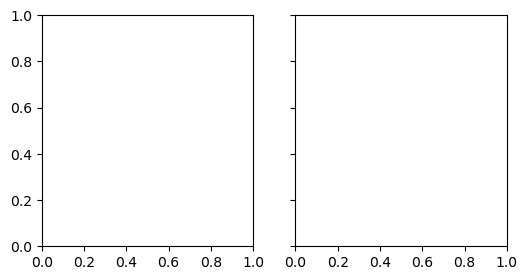

In [18]:
import matplotlib
ceil = 50.0

plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=best_n, sharey=True, figsize=(3*best_n, 3))

for i in range(best_n):
    if best_n == 1:
        ax = axs
    else:
        ax = axs[i]
    
    rpt_rmsds = [rmsds[key][i] for key in rmsds.keys()]
    rpt_pca_rmsds = [pca_rmsds[key][i] for key in pca_rmsds.keys()]
    
    data = [val_set[np.where(val_set <= ceil/10)] for val_set in rpt_rmsds]
    exclusions = [val_set[np.where(val_set > ceil/10)].shape for val_set in rpt_rmsds]
    v1 = ax.violinplot(data, [np.log2(n)-0.05 for n in latents], showextrema=False)
    print(exclusions)
    for b in v1['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further right than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
        b.set_color('r')
    
    v2 = ax.violinplot([10*val_set for val_set in rpt_pca_rmsds], [np.log2(n)+0.05 for n in latents], showextrema=False)\
    
    for b in v2['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further left than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
        b.set_color('b')

    ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax.set_xlabel('N Latents (log2)')
    if i == 0:
        ax.set_ylabel('Reconstruction Error (Angstrom)')

fig.suptitle(f"{model_title_dict[model_name2load]} Reconstruction")
plt.ylim(0, ceil)

plt.savefig(os.path.join(figure_dir, 'reconstruction_rmsd.png'), bbox_inches='tight')

In [21]:
raise Exception('Stop')

Exception: Stop

In [ ]:
exp = 

In [ ]:

decoded, latent_means, latent_vars = exp.state.apply_fn({'params': exp.state.params, 'batch_stats': exp.state.batch_stats},
                                                        exp.test_data, main_key, train=False,
                                                        rngs={'dropout': dropout_key})

In [ ]:
import mdtraj as md

In [ ]:
fname = f'brd4_256_rpt2_recon.dcd'

if decoded.shape[-1] != 3:
    traj_xyz = decoded.reshape(decoded.shape[0], -1, 3)
else:
    traj_xyz = decoded

with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
vals = atom_rmsd(exp.test_data, decoded)

In [ ]:
np.argmax(vals), max(vals)

In [ ]:
exp.json_params['fname_topology']

In [ ]:
fname = f'brd4_256_rpt2_test.dcd'

if decoded.shape[-1] != 3:
    traj_xyz = exp.test_data.reshape(exp.test_data.shape[0], -1, 3)
else:
    traj_xyz = exp.test_data

with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
traj = md.load('Simulation/3mxf_split2.dcd', top = 'Simulation/3mxf_protein_ligand.pdb')

In [ ]:
xyz = traj.xyz[:, traj.top.select('resname LIG'), :]

In [ ]:
com = md.compute_center_of_mass(traj, 'resname LIG')

In [ ]:
com[0]

In [ ]:
for i in range(3):
    plt.hist(com[:, i])
    plt.show()

In [ ]:
xyz.shape

In [ ]:
traj = md.load('brd4_256_rpt2_test.dcd', top='brd4_heavy_only.pdb')

In [ ]:
traj.image_molecules(inplace=True)

In [ ]:
self = HeavyAtom_Analyzer('json_inputs/X006-1/DA_stretch_X006-1/DA_stretch_X006-1_0002_04.json')

In [ ]:
traingrp = self.rootgrp['Train']
testgrp = self.rootgrp['Test']
rmsd_train = np.mean(traingrp['RMSD_Loss_Term'][:, :], axis=-1)
rmsd_test  = np.mean(testgrp['RMSD_Loss_Term'][:, :], axis=-1)

figure_dir = os.path.join(self.data_dir, 'figures')
if not os.path.isdir(figure_dir):
    os.mkdir(figure_dir)

In [ ]:
#RMSD TERM
plt.clf()
_ = plt.plot(np.arange(len(rmsd_train)), rmsd_train, label='Train')
_ = plt.plot(np.arange(len(rmsd_test)), rmsd_test, label='Test')
plt.legend()
#plt.ylim(1, 10)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction RMSD (nm)')
title = f"{self.n_latents} Latents - RMSD Loss Term"
plt.title(title)
#plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
#Perform VAE on Test Data
root_key = jax.random.PRNGKey(15003)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)
decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                          'batch_stats':self.state.batch_stats},
                                                         self.test_data,
                                                         main_key,
                                                         train=False,
                                                         rngs={'params': params_key,
                                                               'dropout': dropout_key})
printf(f"{decoded.shape=}, {latent_means.shape=}, {latent_vars.shape=}")

In [ ]:
#Plot the rmsd histogram of decoded to encoded
rmsd_vals = atom_rmsd(self.test_data, decoded)*10
plt.clf()
_ = plt.hist(rmsd_vals, bins=50)
title = "Reconstruction RMSD"
plt.title(title)
plt.xlabel("RMSD (Angstrom)")
#plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
#Plot the latent dimensional distributions
colors = [(i/self.n_latents, 0.1, (self.n_latents - i)/self.n_latents) for i in range(1, self.n_latents+1)]
plt.clf()
_ = plt.hist(latent_means, bins=100, histtype='step', alpha=0.5, color=colors)
title = 'All Latents'
plt.title(title)
#plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
    
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon

In [ ]:
#Calculate MI/correlation metrics
pearson_Rs = []
MI_regressions = []
for i in range(self.n_latents):
    for j in range(i+1, self.n_latents):
        pearson_Rs.append(stats.pearsonr(latent_means[:, i], latent_means[:, j])[0])
        MI_regressions.append(mutual_info_regression(latent_means[:, i].reshape(-1, 1),
                                                     latent_means[:, j].reshape(-1, 1))[0])
pearson_Rs = jnp.array(pearson_Rs)
MI_regressions = jnp.array(MI_regressions)

In [ ]:
#Plot distribution of pearsons R's between latents
plt.clf()
_ = plt.hist(jnp.abs(pearson_Rs), density=True, bins=20)
title = 'Pearson R'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
#plt.show()
#Plot distribution of Mutual Informations between latents
plt.clf()
_ = plt.hist(MI_regressions, density=True, bins=20)
title = 'Mutual Information'
plt.title(title)
#plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
#Plot the AIC/BIC
ics = []
for i in range(1, 40):
    MM = GaussianMixture(n_components=i).fit(latent_means)
    ics.append((i, MM.aic(latent_means), MM.bic(latent_means)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1], color='blue', label='Akaike Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 1], color='blue')
_ = plt.plot(ics[:, 0], ics[:, 2], color='orange', label='Bayes Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 2], color='orange')
plt.legend()
title = "AIC_BIC"
plt.title(title)
plt.xlabel('Num Components')
#plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
self.epoch = 69696

In [ ]:
#Gaussian Mixture Modeling
component_nums = [1, 1, 2, np.argmin(ics[:, 1])+1, np.argmin(ics[:, 2])+1]
sample_mults = [1, 100, 1, 1, 1]
save_dcds = True


for num_components, mult in zip(component_nums, sample_mults):
    print(num_components, 'start')
    MM = GaussianMixture(n_components=num_components).fit(latent_means)
    samples, _ = MM.sample(latent_means.shape[0]*mult)

    if not os.path.isdir(os.path.join(figure_dir, 'GMM_hists')):
        os.mkdir(os.path.join(figure_dir, 'GMM_hists'))

    print('Latent Figures')
    for i in range(samples.shape[-1]):
        plt.clf()
        _ = plt.hist(latent_means[:,i], bins=25, histtype='step', color='g', label='Encoded from Test', density=True)
        _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b', label='GMM Samples', density=True)
        title = f'Latent {i} - {num_components} Component GMM'
        plt.title(title)
        plt.legend()
        plt.savefig(os.path.join(figure_dir, 'GMM_hists', title+'.png'), dpi=900, bbox_inches='tight')
        #plt.show()

    key = jax.random.PRNGKey(self.epoch)
    main_key, dropout_key = jax.random.split(key, num=2)
    decoded_samples, _ = self.state.apply_fn({'params': self.state.params, 'batch_stats': self.state.batch_stats},
                                          samples, main_key, train=False,
                                          method=self.model.decode,
                                          rngs={'dropout': dropout_key}, mutable=['batch_stats'])
    printf(f"{self.test_data.shape=}, {latent_means.shape=}, {decoded.shape=}, {samples.shape=}, {decoded_samples.shape=}")

    # Contour plot of Test Data, Reconstructed Data, and Generated Data
    fit_all, fit_test = False, True
    print('Fit PCA')
    pca = PCA(n_components=2)
    if fit_all:
        pca.fit(jnp.concatenate((self.test_data, decoded, decoded_samples)))
        pca_test = pca.transform(self.test_data)
    elif fit_test:
        pca_test = pca.fit_transform(self.test_data)
    pca_recon = pca.transform(decoded)
    pca_gener = pca.transform(decoded_samples)
    
    names = ["Test Set", "Reconstructed", "Generated"]
    colors = ['red', 'green', 'blue']
    xx, yy = np.meshgrid(np.linspace(pca_test[:,0].min()-2, pca_test[:,0].max()+2, 100),
                         np.linspace(pca_test[:,1].min()-2, pca_test[:,1].max()+2, 100))

    if save_dcds:
        save_dcd(os.path.join(figure_dir,
                              f"{num_components}_Component_{decoded_samples.shape[0]:1.1E}_Samples.dcd"),
                 decoded_samples)
    
    print('Make Contour')
    custom_lines = []
    for i, data in enumerate([pca_test, pca_recon, pca_gener]):
        kde = gaussian_kde(data.T)
        z = kde(np.vstack([xx.flatten(), yy.flatten()]))
        z = z.reshape(xx.shape)
        levels = np.linspace(z.max()*0.4, z.max(), 3)
        plt.contour(xx, yy, z, colors=colors[i], levels=levels)
        custom_lines.append(plt.Line2D([0], [0], color=colors[i], lw=3))
    lgd = plt.legend(custom_lines, names, bbox_to_anchor=(1.32,1))
    title = f'PCA Contour Comparison - {num_components} Component GMM - {decoded_samples.shape[0]:1.1E} Samples'
    plt.title(title)
    #plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
    plt.show()

    plt.clf()
    custom_lines = []
    for i, data in enumerate([pca_test, pca_recon, pca_gener]):
        plt.scatter(data[:,0], data[:,1], color=colors[i], label=names[i], alpha=0.05)
        custom_lines.append(plt.Line2D([0], [0], color=colors[i], lw=3))
    lgd = plt.legend(custom_lines, names, bbox_to_anchor=(1.32,1))
    title = f'PCA Scatter Comparison - {num_components} Component GMM - {decoded_samples.shape[0]:1.1E} Samples'
    plt.title(title)
    #plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
    plt.show()

In [ ]:
#Perform VAE on Test Data
root_key = jax.random.PRNGKey(15003+i)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)
decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                          'batch_stats':self.state.batch_stats},
                                                         self.test_data,
                                                         main_key,
                                                         train=False,
                                                         rngs={'params': params_key,
                                                               'dropout': dropout_key})

In [ ]:
latent_means.shape

In [ ]:
colors = []
for i in range(0, latent_means.shape[0], 20):
    j = i // 2000
    colors.append([j/10, 0.1, (10-j)/10])

colors[::100]

In [ ]:
plt.clf()
plt.scatter(latent_means[::20, 0], latent_means[::20, 1], alpha=0.2, c=colors)
plt.xlabel('Latent 1')
plt.ylabel('Latent 2')
plt.show()

In [ ]:
decoded = self.test_data
d_set = [decoded]
for i in range(5):
    #Perform VAE on Test Data
    root_key = jax.random.PRNGKey(15003+i)
    main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)
    decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                              'batch_stats':self.state.batch_stats},
                                                             decoded,
                                                             main_key,
                                                             train=False,
                                                             rngs={'params': params_key,
                                                                   'dropout': dropout_key})
    d_set.append(decoded)

In [ ]:
num_i = len(d_set)
plt.clf()
for i, decoded in enumerate(d_set):
    s = pca.transform(decoded)
    color = (i/num_i, 0.6*i/num_i, (1-i/num_i))
    plt.scatter(s[:,0], s[:,1], alpha=0.3, color=color)
plt.show()

In [ ]:
#determine indices for best n of 5
best_n = 3

for n_latents, experiment_rpts in experiments.items():
    print(n_latents)
    final_losses = np.array([exp.rootgrp['Test'].variables['RMSD_Loss_Term'][-1] for exp in experiment_rpts])
    ave_losses = np.mean(final_losses, axis=1)
    if False in np.isfinite(ave_losses):
        print(ave_losses)
        sorted_loss = sorted(ave_losses[np.where(np.isfinite(ave_losses))])
    else:
        sorted_loss = sorted(ave_losses)
    best_indices = [int(np.where(ave_losses == sorted_loss_elem)[0]) for sorted_loss_elem in sorted_loss][:best_n]

    experiments[n_latents] = [experiments[n_latents][index] for index in best_indices]

In [ ]:
#make a violoin plot
latents = [int(key) for key in experiments.keys()]

key = jax.random.PRNGKey(6969)
main_key, dropout_key = jax.random.split(key, num=2)

rmsds = {}
for n_latents, exp_set in experiments.items():
    rmsds[n_latents] = []
    for exp in exp_set:
        #Logits is the output of calling the NN (Decoded, Latent_Means, Latent_Vars)
        decoded, latent_means, latent_vars = exp.state.apply_fn({'params': exp.state.params, 'batch_stats': exp.state.batch_stats},
                                                                exp.test_data, main_key, train=False,
                                                                rngs={'dropout': dropout_key})
    
        rmsds[n_latents].append(atom_rmsd(exp.test_data, decoded))

In [ ]:
from sklearn.decomposition import PCA
pca_rmsds = {}
for n_latents, exp_set in experiments.items():
    pca_rmsds[n_latents] = []
    for exp in exp_set:
        pca = PCA(n_components=exp.n_latents)
        pca.fit(exp.train_data)
        comps = pca.transform(exp.test_data)
        pca_test = pca.inverse_transform(pca.transform(exp.test_data))
        pca_rmsds[n_latents].append(atom_rmsd(exp.test_data, pca_test))

In [ ]:
plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(8.5, 3))

for i in range(best_n):
    rpt_rmsds = [rmsds[key][i] for key in rmsds.keys()]
    rpt_pca_rmsds = [pca_rmsds[key][i] for key in pca_rmsds.keys()]
    v1 = axs[i].violinplot([10*val_set for val_set in rpt_rmsds], [np.log2(n) for n in latents], showextrema=False)
    for b in v1['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further right than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
        b.set_color('r')
    
    v2 = axs[i].violinplot([10*val_set for val_set in rpt_pca_rmsds], [np.log2(n) for n in latents], showextrema=False)
    for b in v2['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further left than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
        b.set_color('b')

    axs[i].set_xlabel('N Latents (log2)')
    if i == 0:
        axs[i].set_ylabel('Reconstruction Error (Angstrom)')

fig.suptitle(f"{model_title_dict[model_name2load]} Reconstruction")
plt.savefig(os.path.join(figure_dir, 'reconstruction_rmsd.png'), bbox_inches='tight')
plt.ylim(0, 3)

In [ ]:
raise Exception('STOP')

In [ ]:
#Make the Violin PLots



plt.clf()
plt.figure(figsize=(6.5, 6), dpi=80)

v1 = plt.violinplot([10*val_set for val_set in rmsds], [np.log2(n) for n in latents], showextrema=False)
for b in v1['bodies']:
    b.set_edgecolor('black')
    b.set_alpha(1)
    # get the center
    m = np.mean(b.get_paths()[0].vertices[:, 0])
    # modify the paths to not go further right than the center
    b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
    b.set_color('r')

v2 = plt.violinplot([10*val_set for val_set in pca_rmsds], [np.log2(n) for n in latents], showextrema=False)
for b in v2['bodies']:
    b.set_edgecolor('black')
    b.set_alpha(1)
    # get the center
    m = np.mean(b.get_paths()[0].vertices[:, 0])
    # modify the paths to not go further left than the center
    b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
    b.set_color('b')


plt.title('No-Title')
plt.ylabel('RMSD (Angstrom)')
plt.xlabel('Num Latents (log base 2)')
plt.show()

In [ ]:
plt.hist(rmsds[0])

In [ ]:
class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str], analyzer=NN_Experiment_Analyzer):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        figure(figsize=(3.25, 3), dpi=80)
        plt.rc('font', **{'family' : 'normal', 'weight' : 'bold', 'size'   : 11})
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()

    def potential_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, pots = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            pots.append(jax.jit(scaled_pot_enr_diff)(exp.test_data, recon))
        latents, pots = jnp.array(latents), jnp.array(pots)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(jnp.sqrt(pots), pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('Potential Deviation (%)')
        plt.yscale('log')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

In [ ]:
rpt = 0
darmsd_cards = [f'/media/volume/Josephs-Volume/previous_data/4_24_24/jsons/DA*{rpt}.json',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']

crrmsd_cards = [f'/media/volume/Josephs-Volume/previous_data/4_24_24/jsons/Crambin_AE_*{rpt}.json',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']

bromo_cards = [f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_*{rpt}.json',
               f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']


wd_cards = crrmsd_cards
system = 'Crambin RMSD-Only'

In [ ]:
#No Updates necessary below this line to change systems
json_wildcard, nc_wildcard, ckpt_wildcard = wd_cards

json_fns = sorted(glob.glob(json_wildcard))
netcdf_fns = sorted(glob.glob(nc_wildcard))
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))

checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [ ]:
# rpt = 1
# bromo_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/jsons/3mxf_*{rpt}.json',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# dapot_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/jsons/*{rpt}.json',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# darmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/DA*{rpt}.json',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# crrmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/Crambin_AE_*{rpt}.json',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
# HIV1p_cards = [f'HIV1p_AE_Dropout_RMSD_only/jsons/*{rpt}.json',
#                f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# oxy_cards = [f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*{rpt}.json',
#              f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#              f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
# da_noDrop_rmsd_cards = [f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*{rpt}.json',
#                         f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/*checkpoint.nc',
#                         f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']

# #Use the following rpt for each, respectively, 3, 0, 0, 0, 0, 0, 1, 


# json_wildcard, nc_wildcard, ckpt_wildcard = da_noDrop_rmsd_cards
# system = 'Deca-Alanine No-Dropouts'



# json_fns = sorted(glob.glob(json_wildcard))
# netcdf_fns = sorted(glob.glob(nc_wildcard))
# all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))

# checkpoint_dirs = []
# #Two checkpoints per model, always take the latest one
# indices = range(1, len(all_checkpoint_dirs)+1, 2)
# for ind in indices:
#     checkpoint_dirs.append(all_checkpoint_dirs[ind])

# assert len(json_fns) == len(netcdf_fns)
# assert len(json_fns) == len(checkpoint_dirs)

In [ ]:
for i in range(len(json_fns)):
    print(json_fns[i])
    print(netcdf_fns[i])
    print(checkpoint_dirs[i])
    print('#########################################################')

In [ ]:
json_params_series = []

for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Josephs-Volume/")
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/abahl/",
                                                    "/media/volume/Aryan-s-Volume/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [ ]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs, analyzer=NN_Experiment_Analyzer)

In [ ]:
def plot_results(exp):
    traingrp = exp.rootgrp['Train']
    testgrp = exp.rootgrp['Test']
    keys = ['RMSD']
    plt.clf()
    plt.title('RMSD' + f' {exp.n_latents} Latents')
    for grp in [traingrp, testgrp]:
        _ = plt.plot(np.arange(grp.variables['RMSD'][:, :].shape[0]),
                     np.mean(grp.variables['RMSD'][:, :], axis=1))
    plt.xlabel('Epoch')
    plt.ylabel('RMSD (nm)')
    plt.legend(['Train','Test'])
    plt.show()

    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')

In [ ]:
# for key, exp in self.experiments.items():
#     print(key, exp.model)

In [ ]:
# for key, exp in self.experiments.items():
#     print(key, exp)
#     exp.plot_results()

In [ ]:
def rmsd_violin_plot(self, rng_seed, title):
    #Assemble the Data
    latents, rmsds = [], []
    for key, exp in self.experiments.items():
        print(key)
        latents.append(exp.n_latents)
        recon, _ = exp.operate(rng_seed)
        rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
    latents, rmsds = jnp.array(latents), jnp.array(rmsds)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    plt.title(title)
    plt.ylabel('RMSD (Angstrom)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

In [ ]:
# rmsd_violin_plot(self, rng_seed=98263, title=f'RMSD Error - {system}')

In [ ]:
# for key, exp in self.experiments.items():
#     print(key, 'ran for:', len(exp.rootgrp['Train'].dimensions['epoch']), 'epochs')

In [ ]:
def last_epoch_plot(self, title):
    #Assemble the Data
    latents, epochs = [], []
    for key, exp in self.experiments.items():
        latents.append(exp.n_latents)
        epochs.append(len(exp.rootgrp['Train'].dimensions['epoch']))
    latents, epochs = jnp.array(latents), jnp.array(epochs)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.scatter(pos, epochs/1000)
    plt.title(title)
    plt.ylabel('Last Epoch Reached (10\u00B3)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

In [ ]:
# last_epoch_plot(self, f'Length of Training - {system}')

### something else

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 2 * np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create the plot
plt.plot(x, y1, label='sin(x)')
plt.plot(x, y2, label='cos(x)')

# Fill the area between the lines
plt.fill_between(x, y1, y2, where=(y1 > y2), color='green', alpha=0.3)
plt.fill_between(x, y1, y2, where=(y1 < y2), color='red', alpha=0.3)

# Add a legend and show the plot
plt.legend()
plt.show()

### Compare PCA to AE Reconstruction

In [ ]:
pca_projection = lambda og_data, pca: np.matmul(og_data-pca.mean_, np.matmul(pca.components_.T, pca.components_)) + pca.mean_

def compare_recon_errs(exp):
    if exp.n_latents < 2000:
        pca = PCA(n_components=exp.n_latents)
    else:
        pca = PCA(n_components=2000)
    _ = pca.fit(exp.train_data)
    pca_recon = jnp.array(pca_projection(exp.test_data, pca))
    dec_recon, ae_latent = exp.operate(rng_seed=exp.n_latents)
    err_ae = jax.vmap(atom_rmsd, in_axes=(0, 0))(dec_recon, exp.test_data)
    err_pca = jax.vmap(atom_rmsd, in_axes=(0, 0))(pca_recon, exp.test_data)
    return err_ae, err_pca

In [ ]:
err_sets = {}

for json_params, netcdf_fn, checkpoint_dir, in zip(json_params_series, netcdf_fns, checkpoint_dirs):
    exp = NN_Experiment_Analyzer(json_params, netcdf_fn, checkpoint_dir)
    err_sets[exp.n_latents] = compare_recon_errs(exp)
    del exp

In [ ]:
pos = np.log2(np.array([key for key in err_sets.keys()]))

parts = plt.violinplot([10*val[0] for val in err_sets.values()],
                       pos,
                       showmeans=True, showmedians=False, showextrema=False)

for pc in parts['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(1)
plt.title(f'PCA v AE Reconstruction - {system.split(' ')[0]}')
plt.ylabel('Error AE (Angstrom)')
plt.xlabel('Num Latents (log base 2)')
plt.xticks(pos[pos % 2 == 0])
#plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
plt.hlines(y=0, xmin=0, xmax=11, color='red', linestyles='dashed')
plt.show()

In [ ]:
pos = np.log2(np.array([key for key in err_sets.keys()]))

parts = plt.violinplot([10*val[1] for val in err_sets.values()],
                       pos,
                       showmeans=True, showmedians=False, showextrema=False)

for pc in parts['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(1)
plt.title(f'PCA v AE Reconstruction - {system.split(' ')[0]}')
plt.ylabel('Error PCA (Angstrom)')
plt.xlabel('Num Latents (log base 2)')
plt.xticks(pos[pos % 2 == 0])
#plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
plt.hlines(y=0, xmin=0, xmax=11, color='red', linestyles='dashed')
plt.show()

In [ ]:
#err_sets = {key: 10*(val[1] - val[0]) for key, val in err_sets.items()}

In [ ]:
pos = np.log2(np.array([key for key in err_sets.keys()]))

parts = plt.violinplot([10*(val[1] - val[0]) for val in err_sets.values()],
                       pos,
                       showmeans=True, showmedians=False, showextrema=False)

for pc in parts['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(1)
plt.title(f'PCA v AE Reconstruction - {system.split(' ')[0]}')
plt.ylabel('Error Difference (Angstrom)')
plt.xlabel('Num Latents (log base 2)')
plt.xticks(pos[pos % 2 == 0])
#plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
plt.hlines(y=0, xmin=0, xmax=11, color='red', linestyles='dashed')
plt.show()

#### Perform a Latent Dimension Perturbation

Using the four latent model, perturb each cluster center along each latent axis by a set quantity (0.25?)\
Save each of these perturbed coordinates

In [ ]:
n_latents = 4
n_clusters = 4

rng_seed = 2358

#Perform the kmeans clustering
labels, kmeans = self.experiments['2 Latents'].cluster_test(num_clusters=n_clusters)

#Obtain the centers
centers = kmeans.cluster_centers_
print(centers.shape)

In [ ]:
#Encode (and decode) the centers
exp = self.experiments[f'{n_latents} Latents']
decoded, latent = exp.state.apply_fn({'params':exp.state.params}, centers, rng_seed)
print(decoded.shape, latent.shape)

In [ ]:
#Perturb the centers along each axis by a constant
perturbing_constant = 0.5

perturbed_latents = jnp.empty((n_latents, centers.shape[0], n_latents))
for center_index in range(n_clusters): #iterate over num centers
    for latent_index in range(n_latents):
        perturbing_vector = jnp.zeros(n_latents)
        perturbing_vector = perturbing_vector.at[center_index].set(perturbing_constant)
        perturbed_latents = perturbed_latents.at[latent_index, center_index].set(latent[latent_index] + perturbing_vector)
decoded_perturbed = exp.decode(rng_seed, perturbed_latents)
print(perturbed_latents.shape, decoded_perturbed.shape)

In [ ]:
for perturbed_centroid_index in range(perturbed_latents.shape[0]):
    print('###')
    print(latent[perturbed_centroid_index])
    for perturbed_latent_index in range(perturbed_latents.shape[1]):
        print(perturbed_latents[perturbed_centroid_index, perturbed_latent_index])

In [ ]:
#Grab the Visualization code from other branch and put it here
def create_arrow_bild_file(start_coords, end_coords, output_file, color="blue", size=0.1, shape=0.3, large_arrows_only=True):
    """
    Create a .bild file with arrow representations for each atom showing movement from one trajectory to another.

    Parameters:
    - start_coords (numpy array): Atomic coordinates from the first trajectory (n_atoms, 3).
    - end_coords (numpy array): Atomic coordinates from the second trajectory (n_atoms, 3).
    - output_file (str): The name of the output .bild file to be created.
    - color (str): Color of the arrows (default: "blue").
    - size (float): Size of the arrows (default: 0.1).
    - shape (float): Shape of the arrows (default: 0.3).
    """
    arrow_vectors = end_coords - start_coords #still n_atom by 3
    arrow_magnitudes = jnp.sqrt(jnp.sum(arrow_vectors**2, axis=-1))
    mean_mag, std_mag = arrow_magnitudes.mean(), arrow_magnitudes.std()
    if large_arrows_only:
        min_mag_to_show = mean_mag + std_mag
    else:
        min_mag_to_show = 0
    
    with open(output_file, 'w') as bild_file:
        for start, end, magnitude in zip(start_coords, end_coords, arrow_magnitudes):
            if magnitude >= min_mag_to_show:
                    
                arrow_line = f".color {color}\n" \
                             f".arrow {start[0] * 10} {start[1] * 10} {start[2] * 10} " \
                             f"{end[0] * 10} {end[1] * 10} {end[2] * 10} {size} {shape}\n"
                bild_file.write(arrow_line)

In [ ]:
#Specify the directory to store these files and the colors of different latents
bild_file_directory = f"perturbation/{system.replace(' ','_')}_bild_files"
if not os.path.isdir(bild_file_directory):
    os.mkdir(bild_file_directory)

#Latent 0, 1, 2, 3
cmap = ['magenta', 'cyan', 'green', 'orange']

In [ ]:
#Write the bild files
for perturbed_centroid_index in range(perturbed_latents.shape[0]):
    
    decoded_center_frame = decoded[perturbed_centroid_index]
    
    for perturbed_latent_index in range(perturbed_latents.shape[1]):
        perturbed_decoded_frame = decoded_perturbed[perturbed_centroid_index, perturbed_latent_index]

        bild_file_fn = os.path.join(bild_file_directory, f'{system.replace(' ', '_')}_{n_clusters}clusters_center{perturbed_centroid_index}_latent{perturbed_latent_index}.bild')
        
        create_arrow_bild_file(start_coords=decoded_center_frame.reshape(-1, 3),
                               end_coords=perturbed_decoded_frame.reshape(-1, 3),
                               output_file=bild_file_fn,
                               color=cmap[perturbed_latent_index])


In [ ]:
from openmm.app import AmberPrmtopFile, PDBFile
#Write out the coordinates to a trajectory
def write_pdb_file(prmtop, positions_vec, pdbfile_fn):
    if positions_vec.shape[-1] != 3:
        positions = positions_vec.reshape(-1, 3)
    else:
        positions = positions_vec
    
    with open(pdbfile_fn, 'w') as f:
        PDBFile.writeModel(prmtop.topology, positions*10, file=f)
    return None

In [ ]:
structure_file_directory = f"perturbation/{system.replace(' ','_')}_structures"
if not os.path.isdir(structure_file_directory):
    os.mkdir(structure_file_directory)

In [ ]:
# CHANGE ME IF NECESSARY
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop') #CHANGE ME IF NECESSARY
# CHANGE ABOVE IF NECESSARY


#Write the  centers
for perturbed_centroid_index in range(perturbed_latents.shape[0]):
    decoded_center_frame = decoded[perturbed_centroid_index]
    write_pdb_file(prmtop,
                   decoded_center_frame,
                   os.path.join(structure_file_directory, f"{system.replace(' ', '_')}_decoded_center{perturbed_centroid_index}.pdb"))
    
    #And the perturbed centers
    for perturbed_latent_index in range(perturbed_latents.shape[1]):
        perturbed_decoded_frame = decoded_perturbed[perturbed_centroid_index, perturbed_latent_index]

        write_pdb_file(prmtop,
                       perturbed_decoded_frame,
                       os.path.join(structure_file_directory, f"{system.replace(' ', '_')}_decoded_center{perturbed_centroid_index}_perturbed{perturbed_latent_index}.pdb"))
        


In [ ]:
np.log2(np.array((132, 306, 1926, 6531, 9897)))

In [ ]:
lsize = [16, 64, 512, 512, 2048]
fsize = [132, 306, 1926, 6531, 9897]
for i in range(5):
    print(100*lsize[i]/fsize[i])

In [ ]:
exp = self.experiments['4 Latents']

In [ ]:
rng_seed = 28507

recon, latents = exp.operate(rng_seed)

In [ ]:
latents.shape, recon.shape

In [ ]:
for i in range(latents.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [ ]:
#How much does a perturbation of latent change the atomistic position?
latent_domain_sizes = [np.max(latents[:, i]) - np.min(latents[:, i]) for i in range(latents.shape[-1])]
print(latent_domain_sizes)

In [ ]:
np.sum(np.logspace(-2, 0, 101))

In [ ]:
ave_shifts = np.zeros((102,4))

for i in range(4):
    perturbed = latents.at[:, i].add(latent_domain_sizes[i]/10)
    perturbed_recon = exp.decode(rng_seed, perturbed)
    diff_recon = perturbed_recon - recon
    diff_recon = diff_recon.reshape(diff_recon.shape[0], -1, 3)
    Edist = np.sqrt(np.sum(diff_recon**2, axis=2))
    mean_edist = np.mean(Edist, axis=0)
    ave_shifts[:, i] = mean_edist
    print(mean_edist.shape)
    plt.clf()
    _ = plt.figure(figsize=(6.4, 3), dpi=300)
    _ = plt.bar(np.arange(1, 103), mean_edist*10)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.title(f'Latent {i+1}')
    plt.xlabel('Atom Index')
    plt.ylabel('Positional Change (Angstrom)')
    plt.savefig(f'DA-4Latents-SuPoL{i+1}.png', dpi=600, bbox_inches = "tight")
    plt.show()
    

In [ ]:
import mdtraj as md

In [ ]:
traj = md.load('Simulation/ala_deca_peptide.pdb')

In [ ]:
i = 0
for atom in traj.top.atoms:
    print(i, atom, atom.is_backbone, *ave_shifts[i, :])
    i += 1

In [ ]:
self.potential_violin_plot(rng_seed=98263, title='Potential Energy Error upon Reconstruction - DecaAlanine')

In [ ]:
model = self.experiments['4 Latents']
rng_seed = 92183

In [ ]:
test_data = model.test_data
recon, _ = model.operate(rng_seed)
_, samples_5 = model.gaussian_mm_fit(rng_seed, 5)

In [ ]:
test_ener = gas_fun(test_data)
recon_ener = gas_fun(recon)
ener_5 = gas_fun(model.decode(rng_seed, samples_5))

In [ ]:
plt.clf()
plt.figure(figsize=(3.25, 3))
threshold = 1e3
plt.hist(test_ener, histtype='step', bins=25, density=True)

num_outliers_recon = recon_ener[recon_ener > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_recon} ({100*num_outliers_recon/2000} %)")
plt.hist(recon_ener[recon_ener < threshold], histtype='step', bins=25, density=True)

num_outliers_5 = ener_5[ener_5 > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_5} ({100*num_outliers_5/2000} %)")
plt.hist(ener_5[ener_5 < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(['Original', 'Reconstructed', 'Gaussian MM'])
plt.ylabel('Density')
plt.savefig(f'DA_4_latents_GMM_ener.png', dpi=600, bbox_inches = "tight")
plt.show()

In [ ]:
test, decoded, generated = model.test_decoded_modeled_trajs(rng_seed, 5)

In [ ]:
#Cluster the generated
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
clusters = []
for i in range(2, 10):
    clusters.append(i)
    kmeans = KMeans(n_clusters=i).fit_predict(generated)
    sil_scores.append(silhouette_score(generated, kmeans))

sil_scores = np.array(sil_scores)
clusters = np.array(clusters)


plt.clf()
_ = plt.plot(clusters, sil_scores)
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(generated)

In [ ]:
plt.clf()
_ = plt.hist(jnp.log10(gas_fun(generated)), bins=25, histtype='step', density=True)
_ = plt.hist(jnp.log10(gas_fun(test)), bins=25, histtype='step', density=True)
plt.show()

gas_fun(kmeans.cluster_centers_)

In [ ]:
model = self.experiments['16 Latents']

In [ ]:
variance = lambda x: jnp.sum((x - jnp.mean(x))**2)/x.shape[0]
std_dev = lambda x: jnp.sqrt(variance(x))

def divvy_pdevs(pdevs, n_move):
    return jnp.array([pdevs[i-n_move:i] for i in range(n_move, pdevs.shape[0])])

def calculate_variance_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(variance, in_axes=(0))(pdevs_div)

def calculate_stddev_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(std_dev, in_axes=(0))(pdevs_div)

In [ ]:
n_move = 100

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.legend(['Train', 'Test'])
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.savefig(f'std_dev_of_potential_deviation_{key}.png')
    plt.show()    

In [ ]:
n_move = 10

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.show()

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(100, vars.shape[0]+100), jnp.sqrt(vars))
plt.yscale('log')
plt.show()

In [ ]:
fname = f'{model.model_name}{model.n_latents:04d}_GMM_sample_cluster_centers.dcd'
traj_xyz = kmeans.cluster_centers_.reshape(kmeans.cluster_centers_.shape[0], -1, 3)
with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10)

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Double Digits Latents
plt.clf()
n_latents = 100
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Triple Digits Latents
plt.clf()
n_latents = 1000
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        _, samples = exp.gaussian_mm_fit(rng_seed, 5)
        recon = exp.decode(rng_seed, samples)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
A, B = self.super_traj_construct()

In [ ]:
rmsd = jax.vmap(atom_rmsd)(A, B)

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [ ]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [ ]:
#Write a PDB for visualization with OpenMM

In [ ]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [ ]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')
positions = A[0, :].reshape(-1, 3)
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)